In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (23).zip to archive (23).zip


In [ ]:
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

extract_path = "/content/emotion_data"

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
#paths of train and test data
train_dir = "/content/emotion_data/train"
test_dir = "/content/emotion_data/test"

In [ ]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn pandas joblib

In [ ]:
import os
import zipfile
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input,Rescaling,RandomFlip,RandomRotation,RandomZoom,Conv2D,MaxPooling2D,BatchNormalization,Flatten,Dense,Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
def find_train_test_dirs(base_path):
    train_dir = None
    test_dir = None

    for root, dirs, files_in_dir in os.walk(base_path):
        lower_dirs = [d.lower() for d in dirs]

        if "train" in lower_dirs:
            train_dir = os.path.join(root, dirs[lower_dirs.index("train")])

        if "test" in lower_dirs:
            test_dir = os.path.join(root, dirs[lower_dirs.index("test")])

    return train_dir, test_dir


train_dir, test_dir = find_train_test_dirs(extract_path)

print("Train directory:", train_dir)
print("Test directory:", test_dir)

if train_dir is None or test_dir is None:
    raise ValueError("Train or test folder not found. Make sure your dataset has train and test folders.")

Train directory: /content/emotion_data/train
Test directory: /content/emotion_data/test


In [ ]:
class_folders = sorted(os.listdir(train_dir))

print("Emotion classes found:")
for class_name in class_folders:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)), "images")

Emotion classes found:
angry : 3995 images
disgusted : 436 images
fearful : 4097 images
happy : 7215 images
neutral : 4965 images
sad : 4830 images
surprised : 3171 images


In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int",
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="int",
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 7


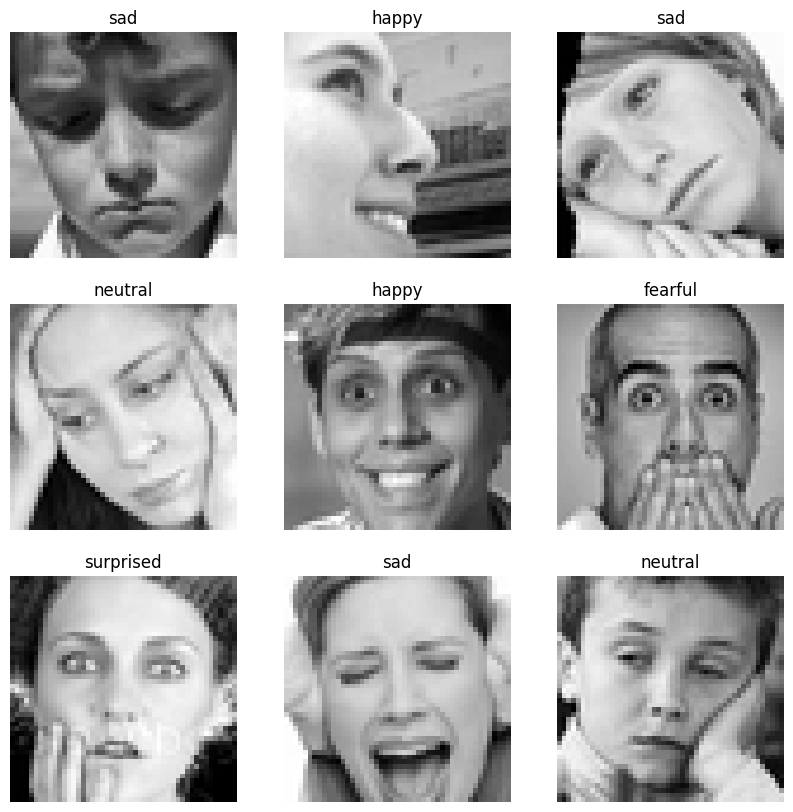

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
model = Sequential([
    Input(shape=(48, 48, 1)),

    # divide every pixel by 255
    Rescaling(1./255),

# rotates flips zooms the image
    RandomFlip("horizontal"),
    RandomRotation(0.08),
    RandomZoom(0.08),

  #cnn block
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

  #flatten and decision layer
    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,423 (2.61 MB)

 Trainable params: 683,975 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
EPOCHS = 25

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.2411 - loss: 1.9742
Epoch 1: val_accuracy improved from None to 0.33853, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 209s 229ms/step - accuracy: 0.2671 - loss: 1.8287 - val_accuracy: 0.3385 - val_loss: 1.6573
Epoch 2/25
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3090 - loss: 1.7218
Epoch 2: val_accuracy improved from 0.33853 to 0.38590, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 258s 225ms/step - accuracy: 0.3232 - loss: 1.6976 - val_accuracy: 0.3859 - val_loss: 1.5679
Epoch 3/25
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3547 - loss: 1.6403
Epoch 3: val_accuracy improved from 0.38590 to 0.41446, saving model to best_emotion_model.keras

Epoch 3: finished saving model to best_emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.5432 - loss: 1.1843
Test Loss: 1.184342861175537
Test Accuracy: 0.5431874990463257


In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

       angry       0.38      0.58      0.46       958
   disgusted       0.20      0.01      0.02       111
     fearful       0.37      0.24      0.29      1024
       happy       0.77      0.79      0.78      1774
     neutral       0.48      0.53      0.51      1233
         sad       0.45      0.40      0.42      1247
   surprised       0.71      0.65      0.68       831

    accuracy                           0.54      7178
   macro avg       0.48      0.46      0.45      7178
weighted avg       0.54      0.54      0.53      7178



In [ ]:
model.save("final_emotion_detection_model.keras")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved successfully.")

Model and class names saved successfully.


In [ ]:
def predict_emotion(image_path):
    original_image, face_image, input_image = preprocess_image_with_face_detection(image_path)

    probabilities = loaded_model.predict(input_image, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_emotion = loaded_class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(face_image, cmap="gray")
    plt.title(f"Predicted Emotion: {predicted_emotion}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    result_df = pd.DataFrame({
        "Emotion": loaded_class_names,
        "Probability": probabilities
    })

    return predicted_emotion, confidence, result_df

Saving download.jpg to download.jpg


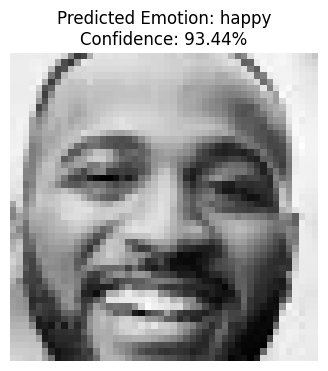

Predicted Emotion: happy
Confidence: 93.44 %


,Emotion,Probability
0,angry,0.010999
1,disgusted,0.000024
2,fearful,0.015312
3,happy,0.934421
4,neutral,0.025782
5,sad,0.010091
6,surprised,0.003372


In [ ]:
uploaded_image = files.upload()

test_image_path = list(uploaded_image.keys())[0]

predicted_emotion, confidence, result_df = predict_emotion(test_image_path)

print("Predicted Emotion:", predicted_emotion)
print("Confidence:", round(confidence, 2), "%")

result_df

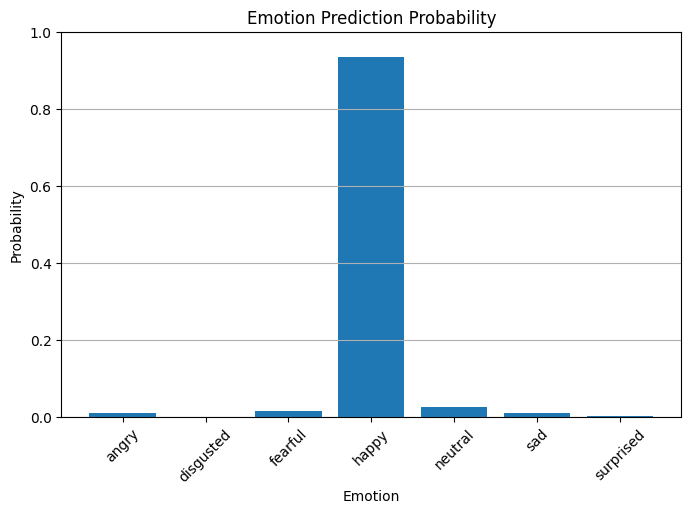

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(result_df["Emotion"], result_df["Probability"])
plt.title("Emotion Prediction Probability")
plt.xlabel("Emotion")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [ ]:
files.download("final_emotion_detection_model.keras")
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving download (1).jpg to download (1).jpg


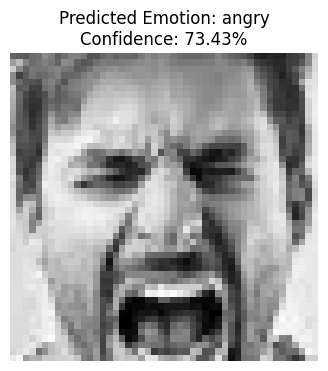

Predicted Emotion: angry
Confidence: 73.43 %


,Emotion,Probability
0,angry,0.734265
1,disgusted,0.006886
2,fearful,0.245659
3,happy,0.001981
4,neutral,0.000153
5,sad,0.010514
6,surprised,0.000542


In [ ]:
uploaded_image = files.upload()

test_image_path = list(uploaded_image.keys())[0]

predicted_emotion, confidence, result_df = predict_emotion(test_image_path)

print("Predicted Emotion:", predicted_emotion)
print("Confidence:", round(confidence, 2), "%")

result_df